# VQE Algorithm based on the following publication:

Paper: https://pubs.acs.org/doi/10.1021/acs.jctc.4c01657

ESI: https://pubs.acs.org/doi/suppl/10.1021/acs.jctc.4c01657/suppl_file/ct4c01657_si_001.pdf

In [65]:
import time
import numpy as np
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import Aer, AerSimulator
from qiskit_aer.primitives import Sampler, EstimatorV2
from qiskit_algorithms import MinimumEigensolverResult
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA, POWELL
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [49]:
# The BeH2 molecule
driver = PySCFDriver(
atom = """ H -1.326, 0.0, 0.0
           Be 0.000, 0.0, 0.0
           H  1.326, 0.0, 0.0
       """,
basis = "sto3g",
charge = 0,
spin = 0
)
# Generating the Electronic Structure Problem
molecule_problem = driver.run()

In [50]:
# Reducing the problem to the active space containing the 2 electrons in the 3 spatial orbitals
active_space_transformer = ActiveSpaceTransformer(
num_electrons =2 , num_spatial_orbitals = 3
)
reduced_molecule_problem = active_space_transformer . transform ( molecule_problem )

In [51]:
# Obtaining the second quantized Hamiltonian
second_q_hamiltonian = reduced_molecule_problem.second_q_ops()[0]

In [52]:
# Defining the Parity mapper
# When the number of particles is given , 2 - qubit tapering is also applied
parity_mapper = ParityMapper(num_particles = reduced_molecule_problem.num_particles)
# Applying the Parity Mapping
qubit_op = parity_mapper.map(second_q_hamiltonian)

In [53]:
ansatz = EfficientSU2(num_qubits = qubit_op.num_qubits, entanglement = "linear", reps = 1)

In [54]:
# Creating a backend
backend = AerSimulator()

# Creating the pass manager that transpiles the ansatz
pm = generate_preset_pass_manager ( backend = backend , optimization_level = 0 )

# Transpiling the ansatz - ISA stands for " Instruction Set Architecture "
isa_ansatz = pm . run ( ansatz )

# Applying the layout of the ISA ansatz to the Hamiltonian observable
# This ensures that the observables qubits are the same as the ansatz qubits
isa_observables = qubit_op . apply_layout ( isa_ansatz . layout )

In [55]:
# Getting the energy value by interpreting the expectation value
# in the context of the reduced molecule problem
def interpret_exp_val ( exp_val , problem ) :
# Wrapping the expectation value in MinimumEigensolverResult
    sol = MinimumEigensolverResult ()
    sol . eigenvalue = np . real ( exp_val )
    # Interpreting the result
    return problem . interpret ( sol ) . total_energies [ 0 ]

In [56]:
# Using the Estimator primitive (noiseless statevector simulator by default)
estimator = EstimatorV2()
# Defining the energy cost function
def energy_cost_function ( params ) :
    # Run the job and get the eigenvalue result
    estimator_job = estimator . run ( [ ( isa_ansatz , isa_observables , params ) ] )
    estimator_exp_val = estimator_job . result () [ 0 ] . data . evs
    # Return the interpreted energy value
    return interpret_exp_val ( estimator_exp_val , reduced_molecule_problem )

In [57]:
# Results list to store the energy values
results = []
# The callback function runs after each COBYLA iteration
def optimizer_callback(params):
    global results
    # Compute current energy at params (COBYLA callback only receives parameters)
    value = energy_cost_function(params)
    results.append(value)
    print(f"Iteration {len(results):03d} - Energy = {value}")

In [58]:
# Defining the COBYLA optimizer
optimizer = COBYLA(maxiter=1000, callback=optimizer_callback)

In [59]:
# Defining random initial parameters
initial_params = np.random.rand(ansatz.num_parameters)

In [60]:
# Running the VQE algorithm
# Classical COBYLA optimizer using the quantum cost function
result = optimizer.minimize(energy_cost_function, initial_params)
# Storing the final energy and parameters
energy_result, parameters_result = result.fun, result.x

Iteration 001 - Energy = -15.16479864149034
Iteration 002 - Energy = -15.16479864149034
Iteration 003 - Energy = -15.16479864149034
Iteration 004 - Energy = -15.16479864149034
Iteration 005 - Energy = -15.169801242264771
Iteration 006 - Energy = -15.184315128872388
Iteration 007 - Energy = -15.206574527854155
Iteration 008 - Energy = -15.21677829061527
Iteration 009 - Energy = -15.218359418032648
Iteration 010 - Energy = -15.218359418032648
Iteration 011 - Energy = -15.222360442707522
Iteration 012 - Energy = -15.222360442707522
Iteration 013 - Energy = -15.228972753421392
Iteration 014 - Energy = -15.228972753421392
Iteration 015 - Energy = -15.235882796586257
Iteration 016 - Energy = -15.241067825517412
Iteration 017 - Energy = -15.242856184339978
Iteration 018 - Energy = -15.250240459130197
Iteration 019 - Energy = -15.255336477384539
Iteration 020 - Energy = -15.260417192905837
Iteration 021 - Energy = -15.265756775208047
Iteration 022 - Energy = -15.26878883408152
Iteration 023 - 

In [86]:
# Bond scan: VQE energy vs Be–H bond distance
distances = np.linspace(1.0, 1.5, 15)  # in Angstrom
scan_energies = []
scan_convergence = []

# Previous optimal parameters for warm-starting the next geometry
prev_opt_params = None

for d in distances:
    # Define linear BeH2-like geometry with one scanned Be–H distance
    driver = PySCFDriver(
        atom=f""" H -1.36,   0.0, 0.0
                  Be 0.00,   0.0, 0.0
                  H {d:.6f}, 0.0, 0.0
              """,
        basis="sto3g",
        charge=0,
        spin=0,
    )
    
    # Electronic structure problem for this geometry
    molecule_problem = driver.run()
    active_space_transformer = ActiveSpaceTransformer(
        num_electrons=2, num_spatial_orbitals=3
    )
    reduced_molecule_problem = active_space_transformer.transform(molecule_problem)
    
    # Map to qubit Hamiltonian
    second_q_hamiltonian = reduced_molecule_problem.second_q_ops()[0]
    parity_mapper = ParityMapper(
        num_particles=reduced_molecule_problem.num_particles
    )
    qubit_op = parity_mapper.map(second_q_hamiltonian)
    
    # Ansatz for this qubit Hamiltonian
    ansatz = EfficientSU2(
        num_qubits=qubit_op.num_qubits, entanglement="linear", reps=1
    )
    
    # Backend and pass manager
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    isa_ansatz = pm.run(ansatz)
    
    # Maybe This is what we needed to do, it is described in the ESI section 4.4
    isa_observables = qubit_op.apply_layout(isa_ansatz.layout)
    
    # Estimator-based cost function for this geometry
    estimator = EstimatorV2()
    def energy_cost_function(params):
        estimator_job = estimator.run([(isa_ansatz, isa_observables, params)])
        estimator_exp_val = estimator_job.result()[0].data.evs
        return interpret_exp_val(estimator_exp_val, reduced_molecule_problem)
    
    # Track convergence for this distance
    energies_this_dist = []
    def optimizer_callback(xk):
        value = energy_cost_function(xk)
        energies_this_dist.append(value)
    
    # Initial parameters: random for first point, then warm-start from previous optimum
    if prev_opt_params is None:
        initial_params = np.random.rand(ansatz.num_parameters)
    else:
        initial_params = prev_opt_params
    
    # COBYLA optimization for this geometry
    optimizer = COBYLA(maxiter=1000, callback=optimizer_callback, tol=1e-6)
    result = optimizer.minimize(energy_cost_function, initial_params)
    energy = result.fun
    
    scan_energies.append(energy)
    scan_convergence.append(energies_this_dist)
    prev_opt_params = result.x
    
    print(f"d = {d:.3f} Å, E = {energy}")

d = 1.000 Å, E = -15.507061092849597
d = 1.036 Å, E = -15.521319312964884
d = 1.071 Å, E = -15.532788743578973
d = 1.107 Å, E = -15.541819312070388
d = 1.143 Å, E = -15.548715025354056
d = 1.179 Å, E = -15.55374029227137
d = 1.214 Å, E = -15.557126623839153
d = 1.250 Å, E = -15.559077681500145
d = 1.286 Å, E = -15.55977412548484
d = 1.321 Å, E = -15.559375771434869
d = 1.357 Å, E = -15.558022327368551
d = 1.393 Å, E = -15.55583318911382
d = 1.429 Å, E = -15.55290915614972
d = 1.464 Å, E = -15.549336335474512
d = 1.500 Å, E = -15.5451907331562


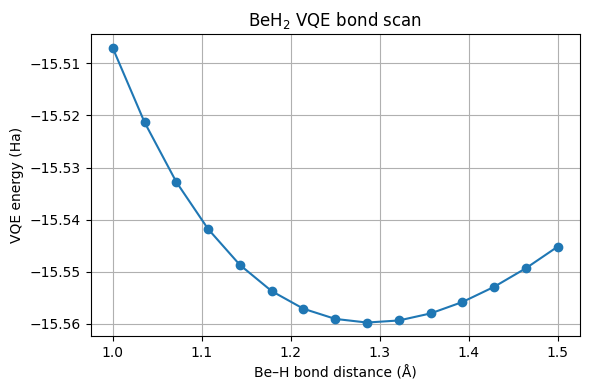

In [87]:
# Plot VQE bond scan results
plt.figure(figsize=(6, 4))
plt.plot(distances, scan_energies, marker="o")
plt.xlabel("Be–H bond distance (Å)")
plt.ylabel("VQE energy (Ha)")
plt.title("BeH$_2$ VQE bond scan")
plt.grid(True)
plt.tight_layout()
plt.show()

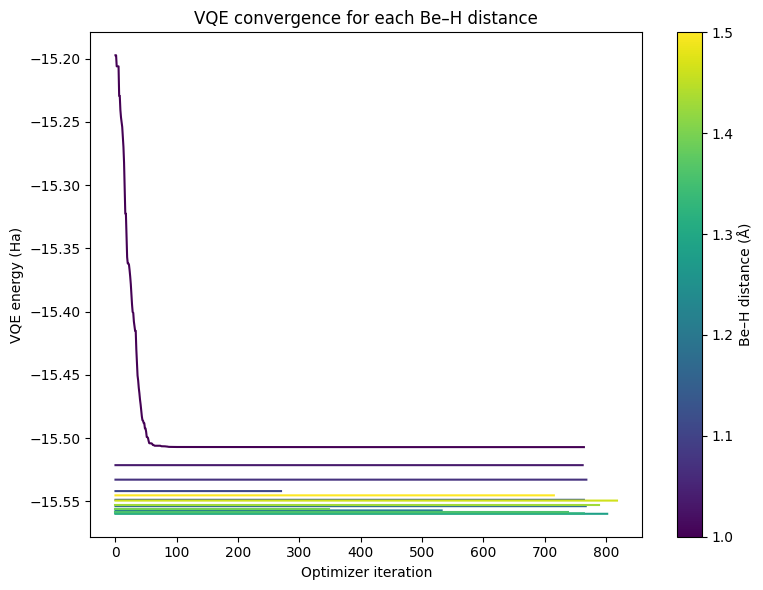

In [88]:
# Plot VQE convergence per bond distance (energy vs optimizer iteration)
plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=float(min(distances)), vmax=float(max(distances)))

for d, energies in zip(distances, scan_convergence):
    iters = range(len(energies))
    color = cmap(norm(float(d)))
    plt.plot(iters, energies, color=color)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.xlabel("Optimizer iteration")
plt.ylabel("VQE energy (Ha)")
plt.title("VQE convergence for each Be–H distance")

ax = plt.gca()
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Be–H distance (Å)")

plt.tight_layout()
plt.show()